# 04 – Visualisation
Règle : **agréger dans Spark**, `toPandas()` uniquement sur le petit résultat.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from shopstream_utils import get_spark, read_table

spark = get_spark("04-viz")
sns.set_theme(style="whitegrid")
hist = read_table(spark, "reviews_history")

Spark 3.5.3 prêt - Spark UI : http://localhost:4040


### 1. Distribution des sentiments par langue

Les avis sont regroupés par langue et par sentiment avant d'être visualisés.

In [5]:
sentiments = read_table(spark, "reviews_sentiment")

sentiment_counts = (
    sentiments
    .groupBy("lang", "sentiment")
    .count()
    .orderBy("lang", "sentiment")
)

sentiment_counts.show()

+----+---------+-----+
|lang|sentiment|count|
+----+---------+-----+
|  en| negative|  261|
|  en|  neutral|   96|
|  en| positive|  683|
|  fr| negative|  595|
|  fr|  neutral|  234|
|  fr| positive| 1658|
+----+---------+-----+



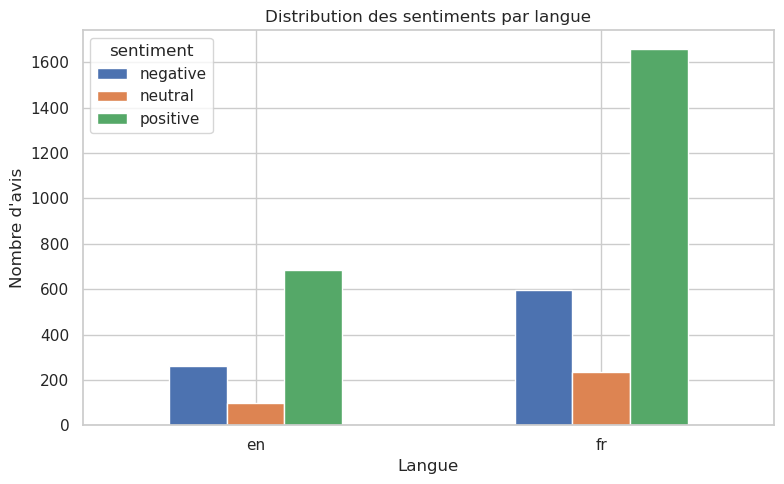

In [6]:
pdf_sentiments = sentiment_counts.toPandas()

pivot_sentiments = (
    pdf_sentiments
    .pivot(index="lang", columns="sentiment", values="count")
    .fillna(0)
)

pivot_sentiments.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution des sentiments par langue")
plt.xlabel("Langue")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Évolution du nombre d'avis dans le temps

L'historique est agrégé par heure afin d'observer les variations d'activité sur la période passée.  
Les données issues du streaming sont déjà agrégées par fenêtre d'une minute dans `stream_window_counts`.

In [7]:
historique_heure = (
    hist
    .withColumn("hour", F.date_trunc("hour", F.col("event_time")))
    .groupBy("hour")
    .count()
    .orderBy("hour")
)

historique_heure.show(10)

+-------------------+-----+
|               hour|count|
+-------------------+-----+
|2026-06-25 00:00:00|   30|
|2026-06-25 01:00:00|   12|
|2026-06-25 02:00:00|   19|
|2026-06-25 03:00:00|   11|
|2026-06-25 04:00:00|    7|
|2026-06-25 05:00:00|   15|
|2026-06-25 06:00:00|   38|
|2026-06-25 07:00:00|   69|
|2026-06-25 08:00:00|   86|
|2026-06-25 09:00:00|   84|
+-------------------+-----+
only showing top 10 rows



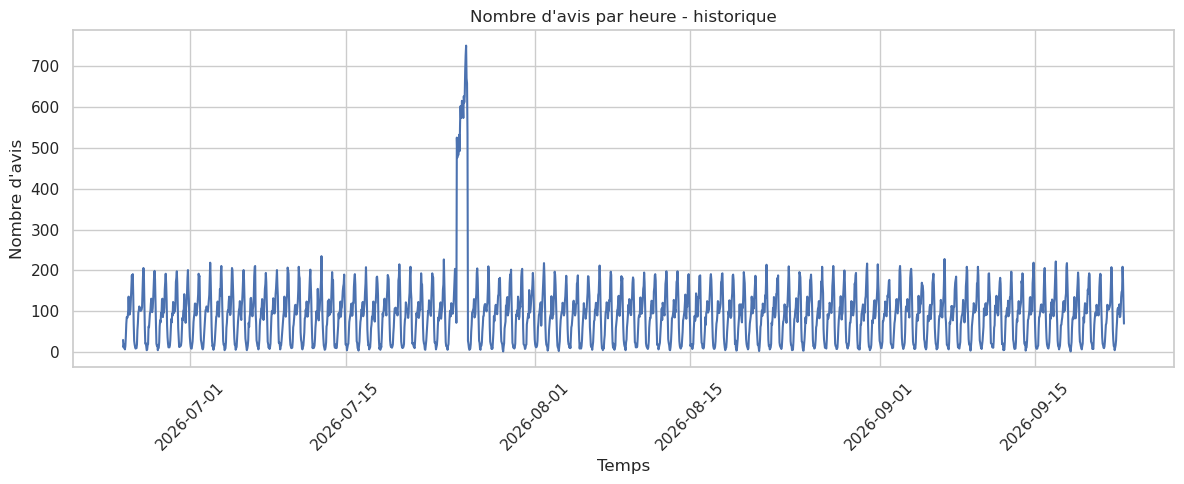

In [8]:
pdf_hist = historique_heure.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf_hist["hour"], pdf_hist["count"])

plt.title("Nombre d'avis par heure - historique")
plt.xlabel("Temps")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
stream_minute = (
    stream_counts
    .groupBy("window_start")
    .agg(F.sum("nb_reviews").alias("nb_reviews"))
    .orderBy("window_start")
)

stream_minute.show(10)

+-------------------+----------+
|       window_start|nb_reviews|
+-------------------+----------+
|2026-09-23 15:19:00|         1|
|2026-09-23 15:20:00|         3|
|2026-09-23 15:21:00|         6|
|2026-09-23 15:22:00|         7|
|2026-09-23 15:23:00|         6|
|2026-09-23 15:24:00|         6|
|2026-09-23 15:25:00|         7|
|2026-09-23 15:26:00|        11|
|2026-09-23 15:27:00|         8|
|2026-09-23 15:28:00|         3|
+-------------------+----------+
only showing top 10 rows



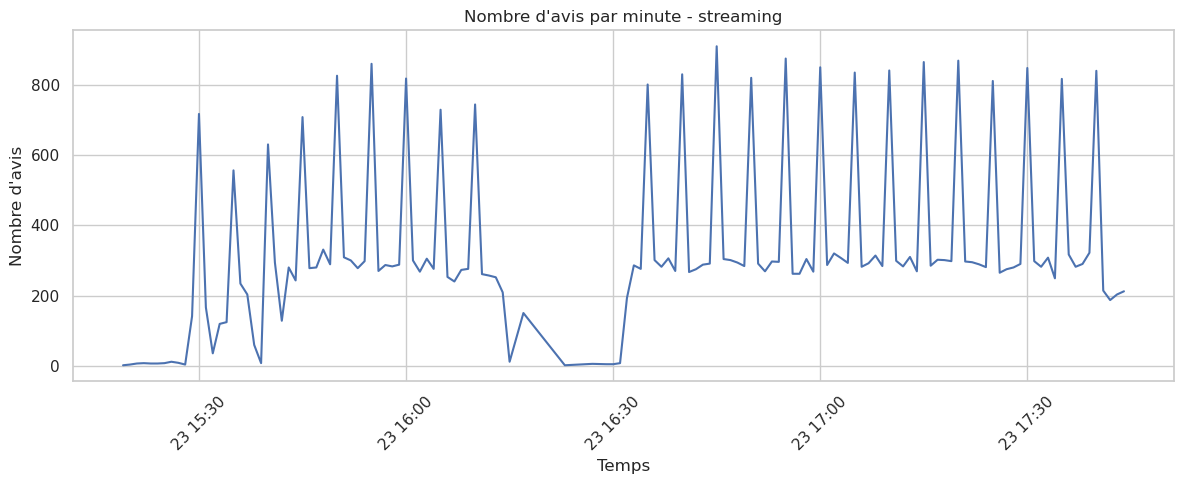

In [4]:
pdf_stream = stream_minute.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf_stream["window_start"], pdf_stream["nb_reviews"])

plt.title("Nombre d'avis par minute - streaming")
plt.xlabel("Temps")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Top 15 hashtags

Les hashtags sont éclatés puis comptés avec Spark afin d'identifier les plus fréquents.  
Seul le résultat agrégé contenant les 15 hashtags les plus utilisés est converti en pandas pour l'affichage.


In [5]:
# TODO 3. Top 15 hashtags (barres horizontales)
top_hashtags = (
    hist
    .select(F.explode("hashtags").alias("hashtag"))
    .groupBy("hashtag")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
)

top_hashtags.show()

+-------------+-----+
|      hashtag|count|
+-------------+-----+
|         #top|15395|
|     #qualite|15370|
|     #bonplan|15345|
|       #happy|15344|
|  #recommande|15267|
|      #beaute|15150|
|   #livraison|15010|
|      #cadeau|14987|
|   #nouveaute|14961|
|        #prix|14929|
| #blackfriday|14890|
|       #promo|14797|
|#electronique|11392|
|       #sport| 7434|
|      #jouets| 6952|
+-------------+-----+



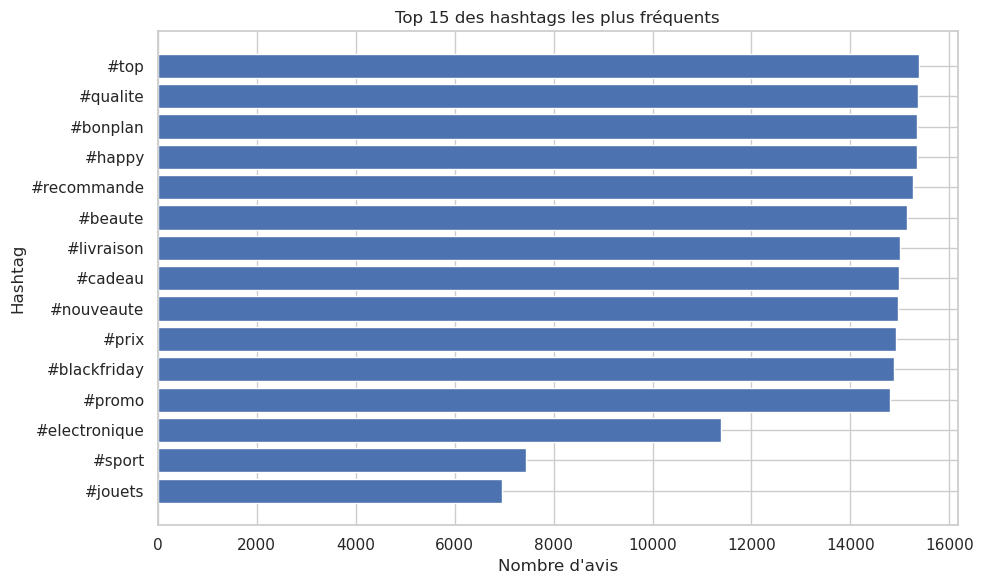

In [6]:
pdf_hashtags = top_hashtags.toPandas()

pdf_hashtags = pdf_hashtags.sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(pdf_hashtags["hashtag"], pdf_hashtags["count"])

plt.title("Top 15 des hashtags les plus fréquents")
plt.xlabel("Nombre d'avis")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

### 4. Activité selon le jour et l'heure

Les avis sont regroupés avec Spark selon le jour de la semaine et l'heure de publication.  
Le résultat agrégé est ensuite converti en pandas afin de construire une heatmap représentant les périodes de plus forte activité.

In [5]:
# TODO 4. Heatmap jour de la semaine x heure
activity = (
    hist
    .withColumn("day_num", F.dayofweek("event_time"))
    .withColumn("hour", F.hour("event_time"))
    .groupBy("day_num", "hour")
    .count()
)

activity.show(10)

+-------+----+-----+
|day_num|hour|count|
+-------+----+-----+
|      3|  20| 2449|
|      6|  18| 1870|
|      5|  12| 1623|
|      3|  18| 1932|
|      3|  22| 1588|
|      7|  12| 2052|
|      5|  23|  843|
|      4|   9| 1042|
|      2|   7|  746|
|      3|  10| 1226|
+-------+----+-----+
only showing top 10 rows



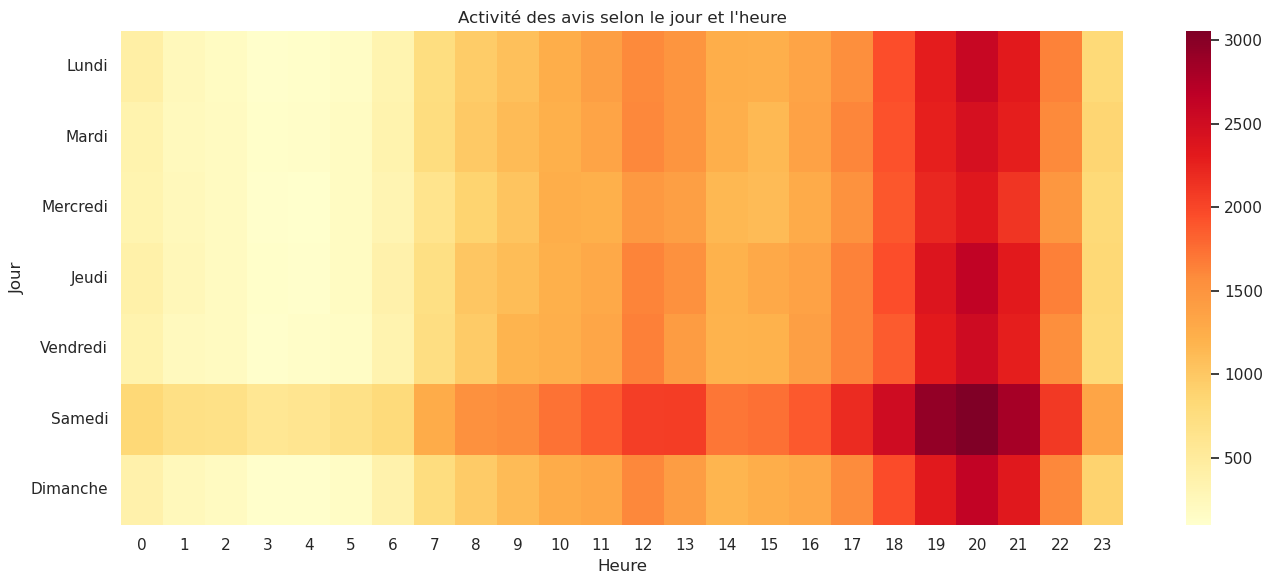

In [6]:
pdf_activity = activity.toPandas()

day_names = {
    1: "Dimanche",
    2: "Lundi",
    3: "Mardi",
    4: "Mercredi",
    5: "Jeudi",
    6: "Vendredi",
    7: "Samedi"
}

pdf_activity["jour"] = pdf_activity["day_num"].map(day_names)

heatmap_data = pdf_activity.pivot(
    index="jour",
    columns="hour",
    values="count"
).fillna(0)

order = [
    "Lundi", "Mardi", "Mercredi",
    "Jeudi", "Vendredi", "Samedi", "Dimanche"
]

heatmap_data = heatmap_data.reindex(order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title("Activité des avis selon le jour et l'heure")
plt.xlabel("Heure")
plt.ylabel("Jour")
plt.tight_layout()
plt.show()

### 5. Insight : note moyenne par catégorie

Les notes moyennes varient peu entre les catégories. La catégorie `electronique`
arrive légèrement en tête avec environ 3,69/5, mais l'écart avec les autres
catégories reste faible.

In [3]:
# TODO 5. Un insight de votre choix (titre = conclusion)

category_rating = (
    hist
    .groupBy("category")
    .agg(F.avg("rating").alias("avg_rating"))
    .orderBy(F.desc("avg_rating"))
)

category_rating.show()

+------------+------------------+
|    category|        avg_rating|
+------------+------------------+
|electronique| 3.690025818009379|
|        mode|3.6897785958991665|
|      livres|3.6894063459570114|
|      jouets|3.6821986366381916|
|alimentation|3.6815542652970077|
|      beaute|  3.67648230793752|
|      maison|3.6720858501477958|
|       sport| 3.664684519296005|
+------------+------------------+



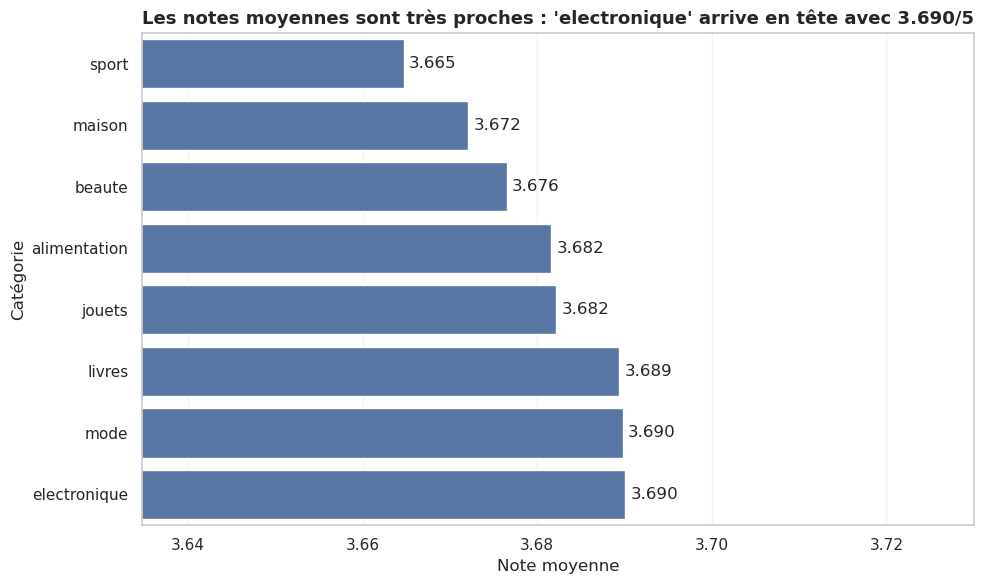

In [7]:
pdf_category = category_rating.toPandas()

# Trier de la moins bien notée à la mieux notée
pdf_category = pdf_category.sort_values("avg_rating")

best_category = pdf_category.iloc[-1]["category"]
best_rating = pdf_category.iloc[-1]["avg_rating"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=pdf_category,
    x="avg_rating",
    y="category"
)

# Afficher la valeur sur chaque barre
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4
    )

# Zoom automatique sur la zone utile
min_rating = pdf_category["avg_rating"].min()
max_rating = pdf_category["avg_rating"].max()

plt.xlim(
    min_rating - 0.03,
    max_rating + 0.04
)

plt.title(
    f"Les notes moyennes sont très proches : "
    f"'{best_category}' arrive en tête avec {best_rating:.3f}/5",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Note moyenne")
plt.ylabel("Catégorie")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Réponses aux questions
- **Q5.1** : Il ne faut pas appeler `toPandas()` sur la table complète car toutes les données Spark seraient rapatriées dans la mémoire du driver. Avec un grand volume de données, cela peut saturer la mémoire et faire planter l'application. Il faut donc effectuer les filtres et les agrégations avec Spark, puis utiliser `toPandas()` uniquement sur le petit résultat agrégé nécessaire à la visualisation.